In [1]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
import optuna
os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
# os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

/opt/pytorch/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
# Basic functions including device and seeding
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("USING DEVICE:", device)

def save_object_to_file(obj, filepath):
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)

def read_object_from_file(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


USING DEVICE: cuda:0


In [3]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_LMP_Forecasts", "FR_lmp_processed.csv")
def split_data(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
    train = df[(df['date'] >= '2019-10-01') & (df['date'] <= '2023-09-30')].reset_index(drop=True)
    dev   = df[(df['date'] >= '2023-10-01') & (df['date'] <= '2024-09-30')].reset_index(drop=True)
    test  = df[(df['date'] >= '2024-10-01') & (df['date'] <= '2025-09-30')].reset_index(drop=True)
    return train, dev, test



In [4]:
#Now construct the training, dev and test sets with 168 possible features being the 168 hourly past prices

def create_sliding_window(data_df, window_size=168, forecast_horizon=1):
    series = data_df['EUR/MWh'].values
    n_samples = len(series) - window_size - forecast_horizon + 1

    X = np.zeros((n_samples, window_size), dtype=np.float32)
    y = np.zeros((n_samples, forecast_horizon), dtype=np.float32)

    for i in range(n_samples):
        X[i] = series[i:i+window_size]
        y[i] = series[i+window_size:i+window_size+forecast_horizon]

    return X, y


In [5]:
ex=split_data(pd.read_csv(DATA_CSV_FR))
train_df, dev_df, test_df = ex[0], ex[1], ex[2]
print(train_df)
X_train, y_train = create_sliding_window(train_df)
X_dev, y_dev     = create_sliding_window(dev_df)
X_test, y_test   = create_sliding_window(test_df)

                            Time  Year  Month  Day  Hour Timezone  EUR/MWh  \
0      2019-10-01 00:00:00+02:00  2019     10    1     0   +02:00    33.09   
1      2019-10-01 01:00:00+02:00  2019     10    1     1   +02:00    27.72   
2      2019-10-01 02:00:00+02:00  2019     10    1     2   +02:00    23.12   
3      2019-10-01 03:00:00+02:00  2019     10    1     3   +02:00    16.46   
4      2019-10-01 04:00:00+02:00  2019     10    1     4   +02:00    15.66   
...                          ...   ...    ...  ...   ...      ...      ...   
35055  2023-09-30 19:00:00+02:00  2023      9   30    19   +02:00   132.03   
35056  2023-09-30 20:00:00+02:00  2023      9   30    20   +02:00   124.28   
35057  2023-09-30 21:00:00+02:00  2023      9   30    21   +02:00   101.06   
35058  2023-09-30 22:00:00+02:00  2023      9   30    22   +02:00   107.40   
35059  2023-09-30 23:00:00+02:00  2023      9   30    23   +02:00   101.04   

            date  
0     2019-10-01  
1     2019-10-01  
2     

In [6]:

# --- Model (MLP) similar structure to Rolling window notebook ---
class MLP(nn.Module):
    def __init__(self, input_dim, layer_dims, output_dim, dropout=0.0, use_batchnorm=False, leaky_alpha=0.0):
        super().__init__()
        layers = []
        last = input_dim
        for i, d in enumerate(layer_dims):
            layers.append(nn.Linear(last, d))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(d, eps=1e-3, momentum=0.99))
            if leaky_alpha and leaky_alpha > 0:
                layers.append(nn.LeakyReLU(leaky_alpha))
            else:
                layers.append(nn.ReLU())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            last = d
        layers.append(nn.Linear(last, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [7]:

# MAE loss (matches TF mae)
def mae_loss_fn(pred, target):
    return torch.mean(torch.abs(pred - target))


In [8]:
def naive_baseline(y_np, shift=24*7):
    out = np.empty_like(y_np, dtype=float)
    out[:shift, :] = np.nan
    out[shift:, :] = y_np[:-shift, :]
    return out


In [9]:
def evaluate_model(model, X_np, y_np, shift=24*7, batch_size=128, device='cpu'):
    model.to(device)
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.from_numpy(X_np[i:i+batch_size]).float().to(device)
            out = model(xb).cpu().numpy()
            preds.append(out)
    predictions = np.vstack(preds)

    if len(y_np) <= shift:
        raise ValueError("Not enough samples to compute naive baseline (need > shift samples).")

    naive_arr = naive_baseline(y_np, shift=shift)
    preds_trim = predictions[shift:]
    true = y_np[shift:]
    naive_vals = naive_arr[shift:]

    mae_model = np.mean(np.abs(preds_trim - true))
    mae_naive = np.mean(np.abs(naive_vals - true))

    if mae_naive == 0:
        rmae = np.inf
        accuracy = -np.inf
    else:
        rmae = mae_model / mae_naive
        accuracy = 1.0 - rmae

    print(f"MAE model: {mae_model:.6f}, MAE naive: {mae_naive:.6f}")
    print(f"Relative MAE (rMAE): {rmae:.4f}, Accuracy (1-rMAE): {accuracy:.4f}")
    return {"predictions": preds_trim, "mae_model": mae_model, "mae_naive": mae_naive, "rmae": rmae, "accuracy": accuracy}

In [24]:
def run_full_train(
        X_train_np, y_train_np, X_dev_np, y_dev_np,
        layer_dims,
        dropout,
        use_batchnorm,
        leaky_alpha,
        learning_rate,
        weight_decay,
        l1_lambda,
        batch_size,
        train_amt,
        epochs,
        verbose_freq=1,
        device='cpu'
    ):

    # --- Use only the first 'train_amt' features (columns) ---
    X_train_np = X_train_np[:, :train_amt]
    X_dev_np = X_dev_np[:, :train_amt]

    input_dim = X_train_np.shape[1]
    output_dim = y_train_np.shape[1]

    MODEL = MLP(
        input_dim=input_dim,
        layer_dims=layer_dims,
        output_dim=output_dim,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
        leaky_alpha=leaky_alpha
    ).to(device)

    optimizer = torch.optim.Adam(
        MODEL.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )


    print("Model:")
    print(MODEL)
    print("Optimizer:", optimizer)
    print(f"Batch size: {batch_size}, Epochs: {epochs}")

    train_hist = []
    val_hist = []

    # --- Convert to tensors once ---
    X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32, device=device)
    y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32, device=device)
    X_dev_tensor = torch.tensor(X_dev_np, dtype=torch.float32, device=device)
    y_dev_tensor = torch.tensor(y_dev_np, dtype=torch.float32, device=device)

    for epoch in range(epochs):
        # --- Shuffle training data ---
        perm = torch.randperm(X_train_tensor.size(0))
        X_shuf = X_train_tensor[perm]
        y_shuf = y_train_tensor[perm]

        MODEL.train()
        epoch_train_loss = 0.0

        for i in range(0, X_shuf.size(0), batch_size):
            xb = X_shuf[i:i+batch_size]
            yb = y_shuf[i:i+batch_size]

            optimizer.zero_grad()
            pred = MODEL(xb)
            loss = mae_loss_fn(pred, yb)

            if l1_lambda and l1_lambda > 0:
                l1_reg = sum(torch.sum(torch.abs(p)) for p in MODEL.parameters())
                loss = loss + l1_lambda * l1_reg

            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item() * xb.size(0)

        epoch_train_loss /= X_shuf.size(0)
        train_hist.append(epoch_train_loss)

        # --- Validation ---
        MODEL.eval()
        with torch.no_grad():
            preds = MODEL(X_dev_tensor)
            val_loss = mae_loss_fn(preds, y_dev_tensor).item()

        val_hist.append(val_loss)
        

        if verbose_freq and (epoch % verbose_freq == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {val_loss:.6f}")

    return MODEL, train_hist, val_hist


In [11]:

# --- Main: load CSV, prepare sliding windows, normalize, quick experiments ---
SEED = 42
seed_everything(SEED)

df_FR = pd.read_csv(DATA_CSV_FR)

train_df_FR, dev_df_FR, test_df_FR = split_data(df_FR)
#Normalization
mean_FR = train_df_FR['EUR/MWh'].mean()
std_FR = train_df_FR['EUR/MWh'].std()
train_df_FR['EUR/MWh'] = (train_df_FR['EUR/MWh'] - mean_FR) / std_FR
dev_df_FR['EUR/MWh'] = (dev_df_FR['EUR/MWh'] - mean_FR) / std_FR
test_df_FR['EUR/MWh'] = (test_df_FR['EUR/MWh'] - mean_FR) / std_FR




In [12]:

X_train_FR, y_train_FR = create_sliding_window(train_df_FR)
X_dev_FR, y_dev_FR     = create_sliding_window(dev_df_FR)
X_test_FR, y_test_FR   = create_sliding_window(test_df_FR)
print("Combined training samples:", X_train_FR.shape, y_train_FR.shape)
print("Combined dev samples:", X_dev_FR.shape, y_dev_FR.shape)
print("Combined test samples:", X_test_FR.shape, y_test_FR.shape)



Combined training samples: (34892, 168) (34892, 1)
Combined dev samples: (8615, 168) (8615, 1)
Combined test samples: (8591, 168) (8591, 1)


In [26]:
def objective(trial):
    # --- Hyperparameters to tune ---
        # --- Architecture search ---
    n_layers = trial.suggest_int("n_layers", 2, 4)
    # Choose number of neurons for each layer
    neuron_choices = [1,32,64,128,192,256]
    layer_dims = [trial.suggest_categorical(f"n_units_l{i}", neuron_choices) for i in range(n_layers)]
    
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    use_batchnorm = trial.suggest_categorical("use_batchnorm", [True, False])
    leaky_alpha = trial.suggest_float("leaky_alpha", 0.0, 0.2)
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-1)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
    l1_lambda = trial.suggest_loguniform("l1_lambda", 1e-7, 1e-3)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    train_amt = trial.suggest_categorical("train_amt", [24, 48, 72, 96, 120, 144, 168])
    epochs = 20  # you can reduce for faster search

    # --- Train model ---
    MODEL, train_hist, val_hist = run_full_train(
        X_train_np=X_train_FR, y_train_np=y_train_FR,
        X_dev_np=X_dev_FR, y_dev_np=y_dev_FR,
        layer_dims=layer_dims,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
        leaky_alpha=leaky_alpha,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        l1_lambda=l1_lambda,
        batch_size=batch_size,
        train_amt=train_amt,
        epochs=epochs,
        verbose_freq=None
    )

    # --- Evaluate on dev set ---
    metrics = evaluate_model(MODEL, X_dev_FR[:, :train_amt], y_dev_FR)

    rmae = metrics["rmae"]  # smaller = better

    return rmae


# --- Run the study ---
study = optuna.create_study(
    direction="minimize",  # minimize relative MAE
    study_name="FR_LMP_MLP"
)
study.optimize(objective, n_trials=50, timeout=None)

print("Best trial:")
best_trial = study.best_trial
print(f"  Value (rMAE): {best_trial.value:.4f}")
for k, v in best_trial.params.items():
    print(f"  {k}: {v}")


[I 2025-11-06 03:14:31,504] A new study created in memory with name: FR_LMP_MLP
/tmp/ipykernel_4303/2308124350.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-1)
/tmp/ipykernel_4303/2308124350.py:13: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
/tmp/ipykernel_4303/2308124350.py:14: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  l1_lambda = trial.suggest_loguniform("l1_lambda

Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=168, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.09353300078954721)
    (3): Dropout(p=0.26713596420936203, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.09353300078954721)
    (7): Dropout(p=0.26713596420936203, inplace=False)
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.013124649357828703
    maximize: False
    weight_decay: 2.4491845391848708e-05
)
Batch size: 64, Epochs: 20


[I 2025-11-06 03:15:02,900] Trial 0 finished with value: 0.4653932651179475 and parameters: {'n_layers': 2, 'n_units_l0': 128, 'n_units_l1': 128, 'dropout': 0.26713596420936203, 'use_batchnorm': True, 'leaky_alpha': 0.09353300078954721, 'learning_rate': 0.013124649357828703, 'weight_decay': 2.4491845391848708e-05, 'l1_lambda': 1.7813801457621055e-06, 'batch_size': 64, 'train_amt': 168}. Best is trial 0 with value: 0.4653932651179475.


MAE model: 0.101040, MAE naive: 0.217107
Relative MAE (rMAE): 0.4654, Accuracy (1-rMAE): 0.5346
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=168, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.016372928054146897)
    (3): Dropout(p=0.3597374034677918, inplace=False)
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.016372928054146897)
    (7): Dropout(p=0.3597374034677918, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.027594895616005904
    maximize: False
    weight_decay: 5.610

[I 2025-11-06 03:15:23,085] Trial 1 finished with value: 0.6608549655876815 and parameters: {'n_layers': 2, 'n_units_l0': 256, 'n_units_l1': 64, 'dropout': 0.3597374034677918, 'use_batchnorm': True, 'leaky_alpha': 0.016372928054146897, 'learning_rate': 0.027594895616005904, 'weight_decay': 5.610968296581926e-06, 'l1_lambda': 6.679998249556942e-05, 'batch_size': 128, 'train_amt': 168}. Best is trial 0 with value: 0.4653932651179475.


...

MAE model: 0.114310, MAE naive: 0.217107
Relative MAE (rMAE): 0.5265, Accuracy (1-rMAE): 0.4735
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.02732190554055194)
    (3): Dropout(p=0.015777592272507412, inplace=False)
    (4): Linear(in_features=64, out_features=192, bias=True)
    (5): BatchNorm1d(192, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.02732190554055194)
    (7): Dropout(p=0.015777592272507412, inplace=False)
    (8): Linear(in_features=192, out_features=1, bias=True)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0017873577060704756
    maximize: False
    weight_decay: 9.4

[I 2025-11-06 03:16:13,403] Trial 5 finished with value: 1.0635138112872038 and parameters: {'n_layers': 2, 'n_units_l0': 64, 'n_units_l1': 192, 'dropout': 0.015777592272507412, 'use_batchnorm': True, 'leaky_alpha': 0.02732190554055194, 'learning_rate': 0.0017873577060704756, 'weight_decay': 9.484257437179235e-05, 'l1_lambda': 2.9775836757533103e-07, 'batch_size': 256, 'train_amt': 24}. Best is trial 0 with value: 0.4653932651179475.


MAE model: 0.230896, MAE naive: 0.217107
Relative MAE (rMAE): 1.0635, Accuracy (1-rMAE): -0.0635
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=48, out_features=192, bias=True)
    (1): BatchNorm1d(192, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.18695558159551393)
    (3): Dropout(p=0.4031542726943468, inplace=False)
    (4): Linear(in_features=192, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.18695558159551393)
    (7): Dropout(p=0.4031542726943468, inplace=False)
    (8): Linear(in_features=32, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.18695558159551393)
    (11): Dropout(p=0.4031542726943468, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)
Optimizer: Adam (
Para

[W 2025-11-06 03:16:29,941] Trial 6 failed with parameters: {'n_layers': 3, 'n_units_l0': 192, 'n_units_l1': 32, 'n_units_l2': 32, 'dropout': 0.4031542726943468, 'use_batchnorm': True, 'leaky_alpha': 0.18695558159551393, 'learning_rate': 0.0049908837141952305, 'weight_decay': 1.6633873210895588e-05, 'l1_lambda': 1.1762552930688722e-07, 'batch_size': 64, 'train_amt': 48} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/pytorch/lib/python3.12/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_4303/2308124350.py", line 20, in objective
    MODEL, train_hist, val_hist = run_full_train(
                                  ^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_4303/4094636035.py", line 68, in run_full_train
    pred = MODEL(xb)
           ^^^^^^^^^
  File "/opt/pytorch/lib/python3.12/site-packages/torch/nn/modules/module.py", line 1773, 

KeyboardInterrupt: 

In [20]:

# experiment config(s) (keeps logic/content from notebook)
all_exp_params = {
    "default": {
        "layer_dims": [120,96,168,1],  #[168,24,1] (lr 1e-4) works good [168,48,24] (lr (5e-5)) as well
        "dropout": 0.03573109906556793,
        "use_batchnorm": False,
        "leaky_alpha": 0.14587229765444704,
        "learning_rate": 0.005843029267463049,
        "weight_decay": 1.5905937067583313e-06,
        "l1_lambda": 3.1555501434057034e-06,
        "batch_size": 64,
        "train_amt": len(X_train_FR),   # use all by default
        "epochs": 200
     },
}

results_save_path = "rolling_window_exp_results.pkl"
plot_suffix = "_loss_plot.jpg"
exp_results = {}
for tag, params in all_exp_params.items():
    print("Running experiment:", tag)
    model, train_hist, val_hist = run_full_train(
        X_train_FR, y_train_FR, X_dev_FR, y_dev_FR,
        layer_dims = params["layer_dims"],
        dropout = params["dropout"],
        use_batchnorm = params["use_batchnorm"],
        leaky_alpha = params["leaky_alpha"],
        learning_rate = params["learning_rate"],
        weight_decay = params["weight_decay"],
        l1_lambda = params.get("l1_lambda", 0.0),
        batch_size = params["batch_size"],
        train_amt = params["train_amt"],
        epochs = params["epochs"],
        verbose_freq = 1
    )
    # evaluate dev set (rMAE etc)
    print("Evaluating on dev set:")
    eval_res = evaluate_model(model, X_dev_FR, y_dev_FR, device=device)
    exp_results[tag] = {"train_loss": train_hist, "val_loss": val_hist, "eval": eval_res}
    
save_object_to_file(exp_results, results_save_path)
exp_results = read_object_from_file(results_save_path)

for tag, r in exp_results.items():
    tr = r["train_loss"]
    va = r["val_loss"]
    plt.clf()
    plt.plot(range(len(tr)), tr, label="Train Loss")
    plt.plot(range(len(va)), va, label="Validation Loss")
    plt.title(f"{tag} Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend(loc="upper right")
    plt.savefig(tag + plot_suffix)
    plt.clf()
plt.show()

Running experiment: default
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=168, out_features=120, bias=True)
    (1): LeakyReLU(negative_slope=0.14587229765444704)
    (2): Dropout(p=0.03573109906556793, inplace=False)
    (3): Linear(in_features=120, out_features=96, bias=True)
    (4): LeakyReLU(negative_slope=0.14587229765444704)
    (5): Dropout(p=0.03573109906556793, inplace=False)
    (6): Linear(in_features=96, out_features=168, bias=True)
    (7): LeakyReLU(negative_slope=0.14587229765444704)
    (8): Dropout(p=0.03573109906556793, inplace=False)
    (9): Linear(in_features=168, out_features=1, bias=True)
    (10): LeakyReLU(negative_slope=0.14587229765444704)
    (11): Dropout(p=0.03573109906556793, inplace=False)
    (12): Linear(in_features=1, out_features=1, bias=True)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach:

<Figure size 640x480 with 0 Axes>

ValueError: x and y must have same first dimension, but have shapes (168,) and (1176,)

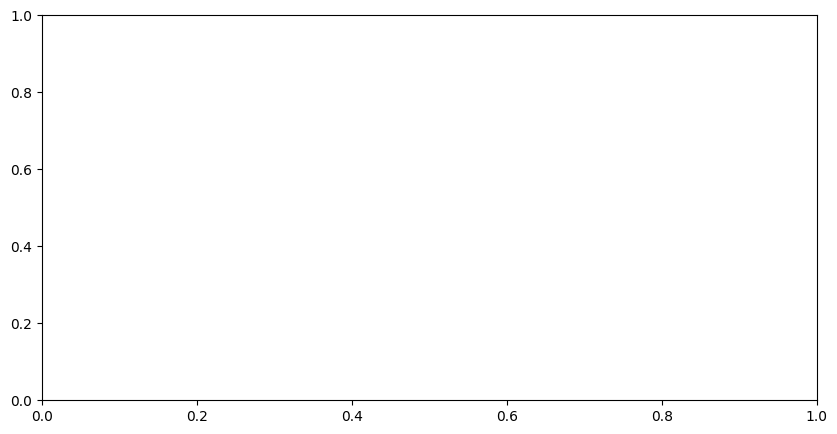

In [ ]:

# Pick three days at random on the dev set and plot single-point forecast + naive baseline
num_days = len(X_dev_FR)
random_indices = random.sample(range(num_days), 3)
naive_arr = naive_baseline(y_dev_FR, shift=24*7)   # do NOT shadow the function name

for idx in random_indices:
    input_window = X_dev_FR[idx]
    true_value = float(y_dev_FR[idx].flatten()[0])  # scalar target
    naive_value = float(np.squeeze(naive_arr[idx]))  # scalar (may be nan for early indices)

    model.eval()
    with torch.no_grad():
        input_tensor = torch.from_numpy(input_window).float().unsqueeze(0).to(device)
        pred_val = float(model(input_tensor).cpu().numpy().flatten()[0])

    plt.figure(figsize=(10, 5))
    plt.plot(np.arange(t), input_window, label='Input Window (Past Prices)')
    plt.scatter([t], [true_value], color='green', label='True (t+1)', zorder=5)
    plt.scatter([t], [pred_val], color='red', marker='x', s=80, label='Predicted (t+1)', zorder=6)
    plt.scatter([t], [naive_value], color='orange', label='Naive Baseline (168h before)', zorder=4)
    plt.title(f'Price Prediction for Dev Sample Index {idx}')
    plt.xlabel('Time (Hours)')
    plt.ylabel('Normalized Price (EUR/MWh)')
    plt.legend()
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Figure size 640x480 with 0 Axes>

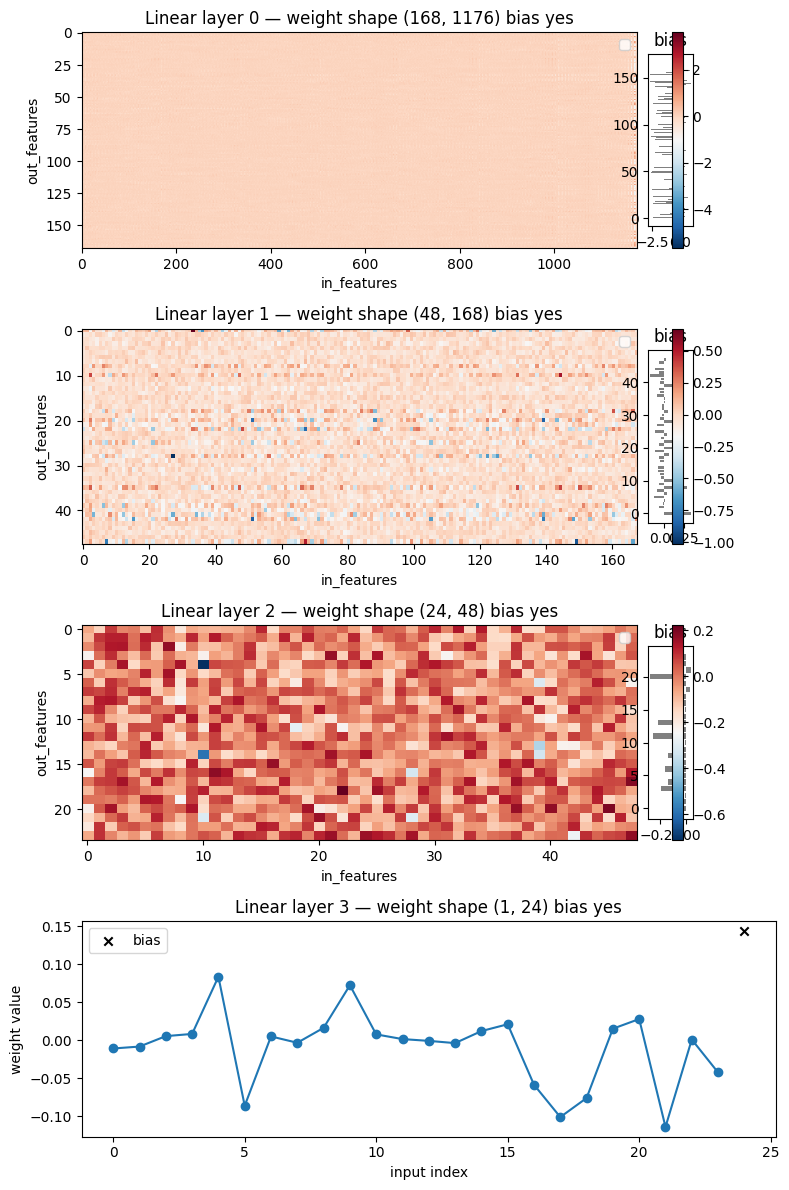

Layer 0: W shape=(168, 1176) ||W||=55.577675 bias=14.221337
Layer 1: W shape=(48, 168) ||W||=9.283781 bias=0.729399
Layer 2: W shape=(24, 48) ||W||=3.265996 bias=0.739941
Layer 3: W shape=(1, 24) ||W||=0.237156 bias=0.143652


In [ ]:


# ensure model is available
_ = model

# move to CPU for plotting
model_cpu = model.to('cpu')

# collect all Linear layers in the sequential network (in order)
linears = [m for m in model_cpu.net if isinstance(m, nn.Linear)]
if len(linears) == 0:
    raise RuntimeError("No nn.Linear layers found in model.net")

# prepare plot
plt.clf()
fig, axes = plt.subplots(len(linears), 1, figsize=(8, 3 * len(linears)))
if len(linears) == 1:
    axes = [axes]

for i, lin in enumerate(linears):
    W = lin.weight.detach().numpy()   # shape: (out_features, in_features)
    b = lin.bias.detach().numpy() if lin.bias is not None else None

    axes[i].set_title(f"Linear layer {i} — weight shape {W.shape} bias {'yes' if b is not None else 'no'}")
    # if single-row output (common for final layer with single output) plot vector
    if W.ndim == 2 and W.shape[0] == 1:
        axes[i].plot(W.flatten(), marker='o', linestyle='-')
        axes[i].set_xlabel("input index")
        axes[i].set_ylabel("weight value")
    else:
        im = axes[i].imshow(W, aspect='auto', cmap='RdBu_r')
        fig.colorbar(im, ax=axes[i])
        axes[i].set_xlabel("in_features")
        axes[i].set_ylabel("out_features")

    # overlay bias as x marks (if present)
    if b is not None:
        # place biases to the right of inputs for visualization (will align on x axis for vector plots)
        if W.shape[0] == 1:
            axes[i].scatter([len(W.flatten())], [b.item()] if b.size == 1 else b.flatten()[0], color='k', marker='x', label='bias')
        else:
            # plot bias values as a separate small bar plot on the right of the heatmap
            bx = axes[i].inset_axes([1.02, 0.1, 0.08, 0.8])
            bx.barh(np.arange(len(b)), b, color='gray')
            bx.set_title("bias")
        axes[i].legend()

plt.tight_layout()
plt.savefig("model_weights.png", bbox_inches='tight')
plt.show()

# print numeric summaries
for i, lin in enumerate(linears):
    W = lin.weight.detach().numpy()
    b = lin.bias.detach().numpy() if lin.bias is not None else None
    print(f"Layer {i}: W shape={W.shape} ||W||={np.linalg.norm(W):.6f} bias={'none' if b is None else np.linalg.norm(b):.6f}")


In [ ]:
print("Evaluating on test set:")
eval_res_test = evaluate_model(model, X_test_FR, y_test_FR, device=device)
exp_results[tag]["eval_test"] = eval_res_test

Evaluating on test set:
MAE model: 0.070978, MAE naive: 0.254058
Relative MAE (rMAE): 0.2794, Accuracy (1-rMAE): 0.7206


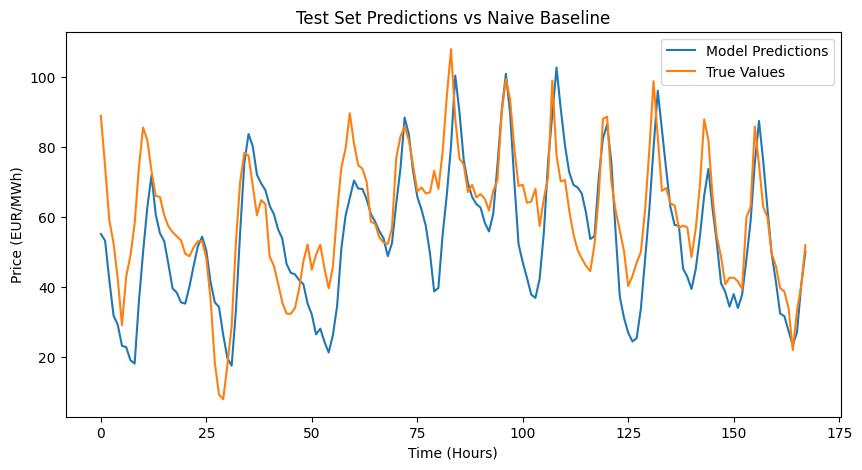

In [ ]:
#Take a random 168 hours window

start = random.randint(0, len(y_dev_FR) - 168 - 1)
window_168 = y_dev_FR[start:start+168]
preds=eval_res['predictions'][start:start+168]
naive_arr = naive_baseline(y_dev_FR, shift=24*7)
naive=naive_arr[start:start+168]
window_168=window_168*std_FR + mean_FR
preds=preds*std_FR + mean_FR
naive=naive*std_FR + mean_FR
#Plot the final predictions on test set
plt.figure(figsize=(10, 5))
plt.plot(preds, label='Model Predictions')
# plt.plot(naive, label='Naive Baseline (168h before)')
plt.plot(window_168, label='True Values')
plt.title('Test Set Predictions vs Naive Baseline')
plt.xlabel('Time (Hours)')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.show()

In [ ]:
#Hyperparameer searching
architectures = [[1],
                [24],
                [48,24],
                [168,24,1],
                [168,48,24]]
lr=np.logspace(-5,-3,5)
results={}
#Train for each of the parameter combinations on 50 epochs
for arch in architectures:
    for learning_rate in lr:
        print(f"Training architecture {arch} with learning rate {learning_rate}")
        model, train_hist, val_hist = run_full_train(
            X_train_FR, y_train_FR, X_dev_FR, y_dev_FR,
            layer_dims = arch,
            dropout = 0.0,
            use_batchnorm = False,
            leaky_alpha = 0.0,
            learning_rate = learning_rate,
            weight_decay = 0.0,
            l1_lambda = 0.0,
            batch_size = 128,
            train_amt = len(X_train_FR),
            epochs = 50,
            verbose_freq = 10
        )
        print("Evaluating on dev set:")
        eval_res = evaluate_model(model, X_dev_FR, y_dev_FR, device=device)
        print("\n")
        results[(tuple(arch), learning_rate)] = eval_res
#Find the best architecture and learning rate
min_rmae=min([v['rmae'] for v in results.values()])
best_configs=[k for k,v in results.items() if v['rmae']==min_rmae]
print(f"Best configurations (rMAE={min_rmae}):")
for config in best_configs:
    print(f"Architecture: {config[0]}, Learning Rate: {config[1]}")


Training architecture [1] with learning rate 1e-05
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=169, out_features=1, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1, out_features=1, bias=True)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0.0
)
Batch size: 128 Epochs: 50
Epoch 1/50 train_loss=0.686255 val_loss=0.398261
Epoch 11/50 train_loss=0.465503 val_loss=0.258371
Epoch 21/50 train_loss=0.425822 val_loss=0.194181
Epoch 31/50 train_loss=0.398131 val_loss=0.151129
Epoch 41/50 train_loss=0.384264 val_loss=0.133377
Evaluating on dev set:
MAE model: 0.123983, MAE naive: 0.217084
Relative MAE (rMAE): 0.5711, Accuracy (1-rMAE): 0.4289


Training architecture [1] with learning rate 3.1622776601683795e-05
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=169, out_feature

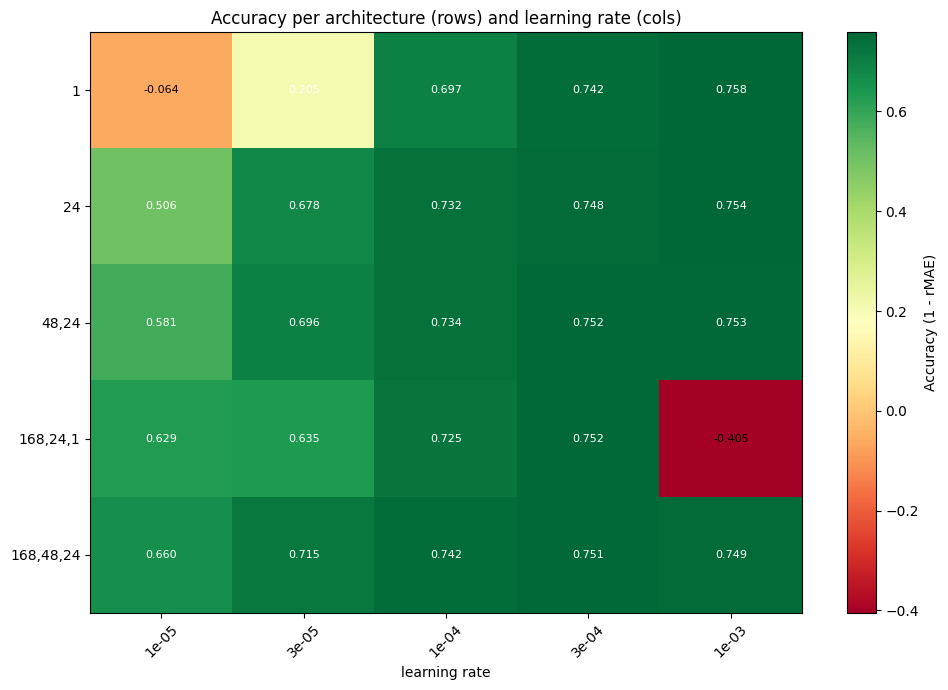

In [ ]:
#Plot now the results : lr vs archtectures 
# collect unique architectures and lrs (same ordering as rMAE plot)
archs = sorted({k[0] for k in results.keys()}, key=lambda a: (len(a), a))
lrs = sorted({float(k[1]) for k in results.keys()})

# build matrix arch x lr of Accuracy = 1 - rMAE (use stored 'accuracy' if present)
amatrix = np.full((len(archs), len(lrs)), np.nan, dtype=float)
for (arch, lr) in results.keys():
    v = results[(arch, lr)]
    # try to get eval-dict (handles both formats)
    if isinstance(v, dict) and "eval" in v and isinstance(v["eval"], dict):
        ev = v["eval"]
    elif isinstance(v, dict) and ("accuracy" in v or "rmae" in v):
        ev = v
    else:
        ev = None

    if ev is None:
        acc = np.nan
    else:
        if "accuracy" in ev and ev["accuracy"] is not None:
            acc = ev["accuracy"]
        elif "rmae" in ev and ev["rmae"] is not None:
            acc = 1.0 - ev["rmae"]
        else:
            acc = np.nan

    i = archs.index(arch)
    j = lrs.index(float(lr))
    amatrix[i, j] = acc

# heatmap (use diverging/green colormap; allow negatives)
vmin = np.nanmin(amatrix)
vmax = np.nanmax(amatrix)
plt.figure(figsize=(10, 4 + 0.6 * len(archs)))
im = plt.imshow(amatrix, aspect='auto', cmap='viridis', origin='upper', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='Accuracy (1 - rMAE)')
plt.yticks(range(len(archs)), [",".join(map(str,a)) for a in archs])
plt.xticks(range(len(lrs)), [f"{lr:.0e}" for lr in lrs], rotation=45)
plt.xlabel("learning rate")
plt.title("Accuracy per architecture (rows) and learning rate (cols)")
for i in range(len(archs)):
    for j in range(len(lrs)):
        val = amatrix[i,j]
        if not np.isnan(val):
            plt.text(j, i, f"{val:.3f}", ha='center', va='center',
                     color='black' if (vmax - vmin) == 0 or val < (vmin+vmax)/2 else 'white', fontsize=8)
plt.tight_layout()
plt.savefig("accuracy_heatmap.png", bbox_inches='tight')
plt.show()